# Сравнение автомобильных рынков России, Европы и Азии

В этом ноутбуке мы собрали в одном месте весь проект: от постановки задачи и загрузки данных до нормализации, подробного анализа и выводов для бизнеса. Наша цель — понять, какие рынки сейчас выглядят интереснее для покупки автомобилей, если считать не только цену объявления, но и итоговую стоимость после ввоза в Россию.

## 1. Описание задачи

Мы рассматриваем задачу со стороны бизнеса, который следит за автомобильным рынком и хочет понимать, где сейчас можно найти более выгодные варианты для закупки. Нам важно не просто посмотреть на цены в объявлениях, а привести все данные к одной логике и сравнить рынки честно.

Для этого мы собираем автомобили из России, Европы, Кореи и других стран Азии, затем переводим цены в рубли, считаем личный ввоз через пошлину, оформление, доставку, документы и утильсбор, а после этого сравниваем итоговую стоимость по моделям и по рынкам.

In [1]:
import logging
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from cars_api import load_authenticated_specs, load_korea_api_data
from cars_dataset import build_all_cars, build_comparison
from cars_http import build_session, format_rates_df, get_cbr_rates
from cars_logging import setup_logging
from cars_reporting import business_summary, summarize_comparison
from cars_sources import load_asia_data, load_europe_data, load_russia_data

warnings.filterwarnings("ignore")

FORCE_REFRESH = False

MARKET_MAP = {
    "Russia": "Россия",
    "Europe": "Европа",
    "Korea": "Корея",
    "Asia": "Азия",
}
METHOD_MAP = {
    "Scraping": "Скрапинг",
    "API": "API",
}
DECISION_MAP = {
    "Import is cheaper": "Ввоз дешевле",
    "Russia is cheaper": "Покупка в России дешевле",
}

pd.options.display.max_columns = 60
pd.options.display.max_rows = 30
pd.options.display.float_format = lambda x: f"{x:,.0f}".replace(",", " ")

sns.set_theme(style="whitegrid")
sns.set_palette(["#1f4e79", "#2a9d8f", "#e76f51", "#e9c46a", "#6c757d"])
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.family"] = "DejaVu Sans"

setup_logging()
logging.getLogger("cars_project").setLevel(logging.WARNING)

def replace_values(frame):
    result = frame.copy()
    if "market_name" in result.columns:
        result["market_name"] = result["market_name"].map(MARKET_MAP).fillna(result["market_name"])
    if "foreign_market" in result.columns:
        result["foreign_market"] = result["foreign_market"].map(MARKET_MAP).fillna(result["foreign_market"])
    if "collection_method" in result.columns:
        result["collection_method"] = result["collection_method"].map(METHOD_MAP).fillna(result["collection_method"])
    if "decision" in result.columns:
        result["decision"] = result["decision"].map(DECISION_MAP).fillna(result["decision"])
    return result

def rename_columns(frame, mapping):
    return replace_values(frame).rename(columns=mapping)

def translate_text(text):
    result = str(text)
    for eng, rus in MARKET_MAP.items():
        result = result.replace(eng, rus)
    for eng, rus in DECISION_MAP.items():
        result = result.replace(eng, rus)
    return result

def show_collection_result(df):
    table = (
        df.groupby(["market_name", "source_portal", "collection_method"], dropna=False)
        .agg(rows=("link", "count"))
        .reset_index()
    )
    table = rename_columns(
        table,
        {
            "market_name": "Рынок",
            "source_portal": "Источник",
            "collection_method": "Способ сбора",
            "rows": "Количество строк",
        },
    )
    display(table)

def show_preview(df, rows=10):
    preview = df[
        [
            "market_name",
            "source_portal",
            "brand",
            "model",
            "model_key",
            "year",
            "price_original",
            "currency",
            "price_rub",
            "estimated_total_rub",
        ]
    ].head(rows)
    preview = rename_columns(
        preview,
        {
            "market_name": "Рынок",
            "source_portal": "Источник",
            "brand": "Марка",
            "model": "Модель",
            "model_key": "Ключ модели",
            "year": "Год",
            "price_original": "Цена в исходной валюте",
            "currency": "Валюта",
            "price_rub": "Цена в рублях",
            "estimated_total_rub": "Итоговая цена с учетом ввоза",
        },
    )
    display(preview)


Сначала мы подключили все нужные функции проекта и подготовили оформление таблиц и графиков. Мы специально сделали это в одной ячейке, чтобы дальше ноутбук оставался аккуратным и читался как цельная работа.

## 2. Сбор данных

In [2]:
session = build_session()
rates = get_cbr_rates(session)
rates_df = format_rates_df(rates).reset_index()
rates_df = rates_df.rename(columns={"index": "Валюта", "rub_per_unit": "Рублей за единицу"})
display(rates_df)


,Валюта,Рублей за единицу
0,RUB,1
1,USD,77
2,EUR,90
3,KRW,0


На первом шаге мы получили курсы валют. Они нужны нам для того, чтобы все цены привести к рублям и потом сравнивать рынки уже в одной системе координат.

In [3]:
korea_df = load_korea_api_data(session, force_refresh=FORCE_REFRESH)
show_collection_result(korea_df)


,Рынок,Источник,Способ сбора,Количество строк
0,Корея,Encar,API,5000


Здесь мы собрали корейский рынок. Это важная часть проекта, потому что Корея у нас загружается через API, а значит мы сразу закрываем одно из ключевых требований задания.

In [4]:
russia_df = load_russia_data(session, force_refresh=FORCE_REFRESH)
show_collection_result(russia_df)


,Рынок,Источник,Способ сбора,Количество строк
0,Россия,Auto.ru,Скрапинг,4143
1,Россия,Youla,API,1357


В этой ячейке мы получили российский рынок. Для России у нас итоговая выборка собрана так, чтобы рынок был достаточно большим и чтобы потом было с чем сравнивать зарубежные варианты.

In [5]:
europe_df = load_europe_data(session, force_refresh=FORCE_REFRESH)
show_collection_result(europe_df)


,Рынок,Источник,Способ сбора,Количество строк
0,Европа,AutoScout24,Скрапинг,5223


Так мы собрали Европу. Здесь основной источник идет через scraping, а часть страниц в проекте дополнительно поддерживается через Selenium, потому что сайт работает динамически.

In [6]:
asia_df = load_asia_data(session, force_refresh=FORCE_REFRESH)
show_collection_result(asia_df)


,Рынок,Источник,Способ сбора,Количество строк
0,Азия,TCV,Скрапинг,5000


Этой ячейкой мы добрали другие страны Азии. Нам было важно, чтобы азиатское направление не сводилось только к Корее, а давало более широкую картину для сравнения.

In [7]:
foreign_for_api = pd.concat([korea_df, asia_df, europe_df], ignore_index=True)
api_specs_df = load_authenticated_specs(session, foreign_for_api, force_refresh=FORCE_REFRESH)
api_demo_df = api_specs_df[["model_key", "api_source", "api_year"]].head(5).copy()

api_table = pd.DataFrame(
    {
        "Часть проекта": [
            "Корея через API",
            "Характеристики через API с ключом",
            "Примеры строк из API с ключом",
        ],
        "Количество строк": [
            len(korea_df),
            len(api_specs_df),
            len(api_demo_df),
        ],
    }
)
display(api_table)


,Часть проекта,Количество строк
0,Корея через API,5000
1,Характеристики через API с ключом,11
2,Примеры строк из API с ключом,5


Здесь мы отдельно показали API-часть проекта. У нас есть и большой массив данных, полученный через API, и отдельный блок с запросами через API-ключ, чтобы эта часть была видна прямо в ноутбуке.

In [8]:
collection_summary = pd.DataFrame(
    {
        "Рынок": ["Россия", "Европа", "Корея", "Азия"],
        "Количество строк": [
            len(russia_df),
            len(europe_df),
            len(korea_df),
            len(asia_df),
        ],
        "Способ сбора": [
            "Скрапинг и API",
            "Скрапинг",
            "API",
            "Скрапинг",
        ],
    }
)
display(collection_summary)


,Рынок,Количество строк,Способ сбора
0,Россия,5500,Скрапинг и API
1,Европа,5223,Скрапинг
2,Корея,5000,API
3,Азия,5000,Скрапинг


В этой таблице видно итоговый объем по каждому рынку. Такой срез помогает сразу убедиться, что выборка у нас большая и что все четыре направления действительно участвуют в проекте.

## 3. Нормализация данных

In [9]:
all_cars = build_all_cars(
    korea_df,
    russia_df,
    europe_df,
    rates,
    api_specs_df,
    asia_df=asia_df,
)
comparison_df = build_comparison(all_cars)

total_table = pd.DataFrame(
    {
        "Рынок": ["Россия", "Европа", "Корея", "Азия", "Общий датасет"],
        "Количество строк": [
            len(russia_df),
            len(europe_df),
            len(korea_df),
            len(asia_df),
            len(all_cars),
        ],
    }
)
display(total_table)
show_preview(all_cars, rows=12)


,Рынок,Количество строк
0,Россия,5500
1,Европа,5223
2,Корея,5000
3,Азия,5000
4,Общий датасет,20723


,Рынок,Источник,Марка,Модель,Ключ модели,Год,Цена в исходной валюте,Валюта,Цена в рублях,Итоговая цена с учетом ввоза
0,Азия,TCV,Alfa Romeo,Alfa Romeo Others,Alfa Romeo Alfa Romeo Others,2 019,8315,USD,640 026,1 824 945
1,Азия,TCV,Alfa Romeo,Alfa Romeo Others,Alfa Romeo Alfa Romeo Others,2 004,7537,USD,580 141,2 025 914
2,Азия,TCV,Alfa Romeo,Brera,Alfa Romeo Brera,2 007,6657,USD,512 405,6 425 217
3,Азия,TCV,Audi,A1,Audi A1,2 017,9421,USD,725 157,1 320 317
4,Азия,TCV,Audi,A1,Audi A1,2 017,7537,USD,580 141,1 175 301
5,Азия,TCV,Audi,A1,Audi A1,2 015,2650,USD,203 977,796 405
6,Азия,TCV,Audi,A3,Audi A3,2 019,12875,USD,991 020,1 719 398
7,Азия,TCV,Audi,A3,Audi A3,2 018,11858,USD,912 739,1 641 117
8,Азия,TCV,Audi,A3,Audi A3,2 017,10049,USD,773 496,1 501 874
9,Азия,TCV,Audi,A3,Audi A3,2 016,4000,USD,307 890,1 032 366


После сбора мы собрали единый общий датасет. На этом шаге все рынки уже приведены к одной структуре, поэтому дальше можно анализировать их вместе, а не как отдельные несвязанные таблицы.

In [10]:
pricing_logic = pd.DataFrame(
    {
        "Этап расчета": [
            "Цена объявления в рублях",
            "Таможенная пошлина",
            "Таможенный сбор за оформление",
            "Доставка до России",
            "Документы и сервис",
            "Утильсбор",
            "Итоговая цена",
        ],
        "Как мы считаем": [
            "Цена объявления умножается на курс валюты",
            "Для личного ввоза зависит от возраста машины, объема двигателя и таможенной стоимости",
            "Берется по шкале от таможенной стоимости автомобиля",
            "Ставим отдельную оценку по каждому направлению ввоза",
            "Сюда входят сертификат, оформление и сервисный сбор",
            "Берем льготный или полный сценарий в зависимости от мощности, объема и возраста",
            "Складываем цену объявления и все расходы на ввоз",
        ],
    }
)
display(pricing_logic)


,Этап расчета,Как мы считаем
0,Цена объявления в рублях,Цена объявления умножается на курс валюты
1,Таможенная пошлина,"Для личного ввоза зависит от возраста машины, ..."
2,Таможенный сбор за оформление,Берется по шкале от таможенной стоимости автом...
3,Доставка до России,Ставим отдельную оценку по каждому направлению...
4,Документы и сервис,"Сюда входят сертификат, оформление и сервисный..."
5,Утильсбор,Берем льготный или полный сценарий в зависимос...
6,Итоговая цена,Складываем цену объявления и все расходы на ввоз


Здесь мы отдельно зафиксировали новую формулу расчета. В проекте мы считаем не абстрактную наценку сверху, а раскладываем ввоз на понятные части: пошлина, оформление, доставка, документы и утильсбор. Из-за этого итоговая цена теперь выглядит гораздо ближе к реальности.

In [11]:
price_preview = rename_columns(
    all_cars[
        [
            "market_name",
            "brand",
            "model_key",
            "year",
            "price_rub",
            "customs_duty_rub",
            "customs_clearance_rub",
            "delivery_rub",
            "certification_rub",
            "broker_service_rub",
            "util_fee_rub",
            "estimated_total_rub",
        ]
    ].head(12),
    {
        "market_name": "Рынок",
        "brand": "Марка",
        "model_key": "Модель",
        "year": "Год",
        "price_rub": "Цена объявления, руб.",
        "customs_duty_rub": "Пошлина, руб.",
        "customs_clearance_rub": "Оформление, руб.",
        "delivery_rub": "Доставка, руб.",
        "certification_rub": "Документы, руб.",
        "broker_service_rub": "Сервисный сбор, руб.",
        "util_fee_rub": "Утильсбор, руб.",
        "estimated_total_rub": "Итоговая цена, руб.",
    },
)
display(price_preview)


,Рынок,Марка,Модель,Год,"Цена объявления, руб.","Пошлина, руб.","Оформление, руб.","Доставка, руб.","Документы, руб.","Сервисный сбор, руб.","Утильсбор, руб.","Итоговая цена, руб."
0,Азия,Alfa Romeo,Alfa Romeo Alfa Romeo Others,2 019,640 026,859 795,4 924,250 000,35 000,30 000,5 200,1 824 945
1,Азия,Alfa Romeo,Alfa Romeo Alfa Romeo Others,2 004,580 141,1 120 649,4 924,250 000,35 000,30 000,5 200,2 025 914
2,Азия,Alfa Romeo,Alfa Romeo Brera,2 007,512 405,1 636 688,4 924,250 000,35 000,30 000,3 956 200,6 425 217
3,Азия,Audi,Audi A1,2 017,725 157,270 036,4 924,250 000,35 000,30 000,5 200,1 320 317
4,Азия,Audi,Audi A1,2 017,580 141,270 036,4 924,250 000,35 000,30 000,5 200,1 175 301
5,Азия,Audi,Audi A1,2 015,203 977,269 766,2 462,250 000,35 000,30 000,5 200,796 405
6,Азия,Audi,Audi A3,2 019,991 020,403 254,4 924,250 000,35 000,30 000,5 200,1 719 398
7,Азия,Audi,Audi A3,2 018,912 739,403 254,4 924,250 000,35 000,30 000,5 200,1 641 117
8,Азия,Audi,Audi A3,2 017,773 496,403 254,4 924,250 000,35 000,30 000,5 200,1 501 874
9,Азия,Audi,Audi A3,2 016,307 890,401 814,2 462,250 000,35 000,30 000,5 200,1 032 366


На примере реальных строк видно, что итоговая цена теперь собирается прозрачно. Это удобно и для анализа, и для объяснения на защите, потому что каждая часть цены видна отдельно.

In [12]:
quality_table = pd.DataFrame(
    {
        "Проверка": [
            "Дубликаты по ссылкам",
            "Незаполненная марка",
            "Незаполненная модель",
            "Незаполненный ключ модели",
            "Нестандартные символы в марке",
            "Нестандартные символы в модели",
            "Нестандартные символы в ключе модели",
        ],
        "Значение": [
            int(all_cars["link"].duplicated().sum()),
            int(all_cars["brand"].isna().sum()),
            int(all_cars["model"].isna().sum()),
            int(all_cars["model_key"].isna().sum()),
            int(all_cars["brand"].fillna("").astype(str).str.contains(r"[^\x00-\x7F]", regex=True).sum()),
            int(all_cars["model"].fillna("").astype(str).str.contains(r"[^\x00-\x7F]", regex=True).sum()),
            int(all_cars["model_key"].fillna("").astype(str).str.contains(r"[^\x00-\x7F]", regex=True).sum()),
        ],
    }
)
display(quality_table)


,Проверка,Значение
0,Дубликаты по ссылкам,0
1,Незаполненная марка,0
2,Незаполненная модель,0
3,Незаполненный ключ модели,0
4,Нестандартные символы в марке,0
5,Нестандартные символы в модели,0
6,Нестандартные символы в ключе модели,0


Этой проверкой мы посмотрели, насколько чисто собран итоговый датасет. Нам было важно убрать дубли, выровнять язык и убедиться, что ключевые поля по марке и модели не разваливаются на разные форматы.

In [13]:
fill_rate_table = pd.DataFrame(
    {
        "Колонка": ["Год", "Пробег", "Объем двигателя", "Мощность", "Тип топлива", "Коробка передач"],
        "Заполнено, %": [
            round(all_cars["year"].notna().mean() * 100, 2),
            round(all_cars["mileage_km"].notna().mean() * 100, 2),
            round(all_cars["engine_cc"].notna().mean() * 100, 2),
            round(all_cars["power_hp"].notna().mean() * 100, 2),
            round(all_cars["fuel_type"].notna().mean() * 100, 2),
            round(all_cars["transmission"].notna().mean() * 100, 2),
        ],
    }
)
display(fill_rate_table)


,Колонка,"Заполнено, %"
0,Год,100
1,Пробег,93
2,Объем двигателя,100
3,Мощность,36
4,Тип топлива,100
5,Коробка передач,100


Здесь мы отдельно посмотрели на заполненность основных характеристик. Это важно, потому что хороший анализ невозможен, если в ключевых колонках слишком много пустых значений.

In [14]:
normalization_sample = rename_columns(
    all_cars[
        [
            "market_name",
            "brand",
            "model",
            "model_key",
            "fuel_type",
            "transmission",
        ]
    ].sample(12, random_state=42),
    {
        "market_name": "Рынок",
        "brand": "Марка",
        "model": "Модель",
        "model_key": "Ключ модели",
        "fuel_type": "Тип топлива",
        "transmission": "Коробка передач",
    },
)
display(normalization_sample)


,Рынок,Марка,Модель,Ключ модели,Тип топлива,Коробка передач
16631,Россия,Geely,Monjaro,Geely Monjaro,Gasoline,Automatic
12780,Корея,Kgmobilriti(ssangyong),Deo Nyu Rekseuteon Seupocheu Kan Dijel 2.2 4WD...,Kgmobilriti(ssangyong) Deo Nyu Rekseuteon Seup...,Diesel,Nan
5568,Европа,Audi,Q7,Audi Q7,Electric,Automatic
18674,Россия,Nissan,Qashqai,Nissan Qashqai,Gasoline,Automatic
20222,Россия,Volkswagen,Lamando,Volkswagen Lamando,Gasoline,Robot
1346,Азия,Mazda,MAZDA3,Mazda MAZDA3,Diesel,Automatic
9841,Европа,Volkswagen,Tiguan,Volkswagen Tiguan,Gasoline,Automatic
17148,Россия,Hyundai,Palisade,Hyundai Palisade,Gasoline,Automatic
10881,Корея,Genesis,GV70 2.5T Gasolrin 2WD (sebudeunggeup Eopseum),Genesis GV70 2.5T Gasolrin 2WD (sebudeunggeup ...,Gasoline,Nan
14651,Корея,Kia,Seupotiji R Dijel 2WD Tlx Gogeuphyeong,Kia Seupotiji R Dijel 2WD Tlx Gogeuphyeong,Diesel,Nan


Этот небольшой срез показывает, как данные выглядят уже после нормализации. Хорошо видно, что марки, модели и основные характеристики приведены к единому формату и выглядят одинаково для разных источников.

## 4. EDA: подробный анализ рынка, марок, моделей, выбросов и графиков

In [15]:
market_table = (
    all_cars.groupby("market_name", dropna=False)
    .agg(
        rows=("link", "count"),
        median_price_rub=("price_rub", "median"),
        median_total_rub=("estimated_total_rub", "median"),
        median_year=("year", "median"),
        median_mileage_km=("mileage_km", "median"),
    )
    .reset_index()
)
market_table = rename_columns(
    market_table,
    {
        "market_name": "Рынок",
        "rows": "Количество объявлений",
        "median_price_rub": "Медианная цена, руб.",
        "median_total_rub": "Медианная итоговая цена, руб.",
        "median_year": "Медианный год",
        "median_mileage_km": "Медианный пробег, км",
    },
)
display(market_table)


,Рынок,Количество объявлений,"Медианная цена, руб.","Медианная итоговая цена, руб.",Медианный год,"Медианный пробег, км"
0,Азия,5000,542 502,1 689 560,2 016,68 582
1,Европа,5223,3 006 401,6 369 490,2 021,75 000
2,Корея,5000,1 179 714,2 258 814,2 021,73 360
3,Россия,5500,1 699 000,1 699 000,2 021,35 000


Сначала мы посмотрели на рынки в целом. Здесь видно, какие направления у нас самые большие по объему, где медианные цены ниже и где в среднем продаются более свежие или более уставшие автомобили.

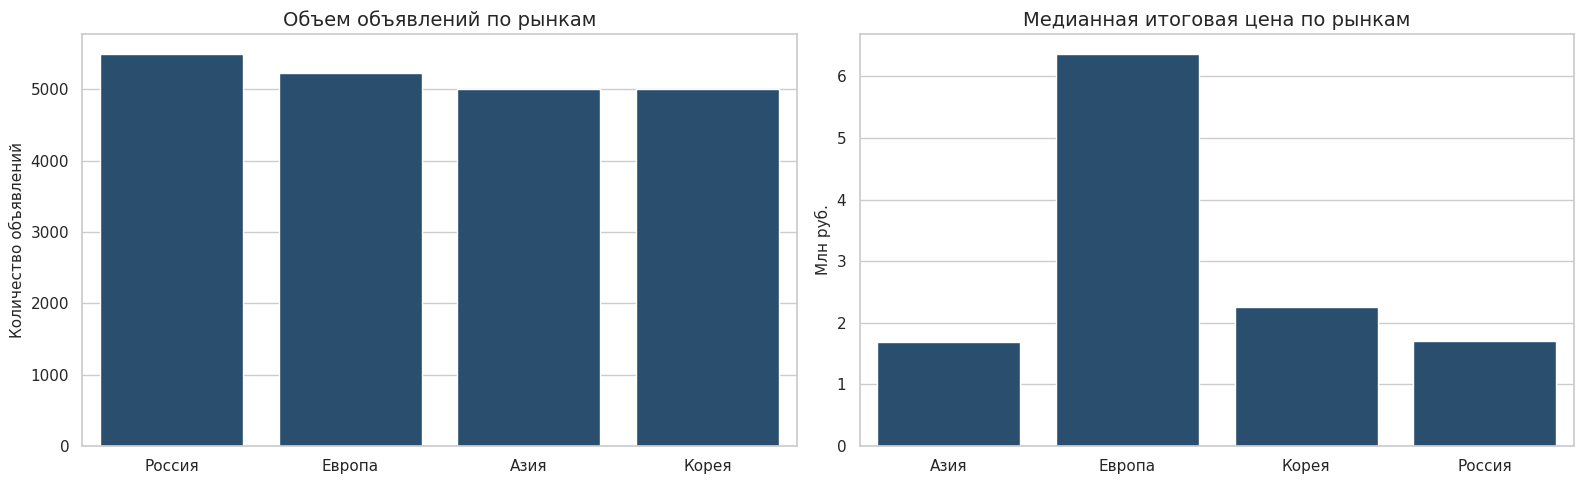

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

market_counts = rename_columns(
    all_cars["market_name"].value_counts().rename_axis("market_name").reset_index(name="rows"),
    {"market_name": "Рынок", "rows": "Количество объявлений"},
)
sns.barplot(data=market_counts, x="Рынок", y="Количество объявлений", ax=axes[0])
axes[0].set_title("Объем объявлений по рынкам")
axes[0].set_xlabel("")
axes[0].set_ylabel("Количество объявлений")

market_price = rename_columns(
    all_cars.groupby("market_name", as_index=False)["estimated_total_rub"].median(),
    {"market_name": "Рынок", "estimated_total_rub": "Медианная итоговая цена"},
)
market_price["Медианная итоговая цена, млн руб."] = market_price["Медианная итоговая цена"] / 1_000_000
sns.barplot(data=market_price, x="Рынок", y="Медианная итоговая цена, млн руб.", ax=axes[1])
axes[1].set_title("Медианная итоговая цена по рынкам")
axes[1].set_xlabel("")
axes[1].set_ylabel("Млн руб.")

plt.tight_layout()
plt.show()


На графиках сразу видна общая структура проекта. Один график показывает, где у нас больше данных, а второй помогает быстро понять, какие рынки выглядят дешевле или дороже уже после учета ввоза.

,Рынок,Способ сбора,Количество объявлений
0,Азия,Скрапинг,5000
1,Европа,Скрапинг,5223
2,Корея,API,5000
3,Россия,API,1357
4,Россия,Скрапинг,4143


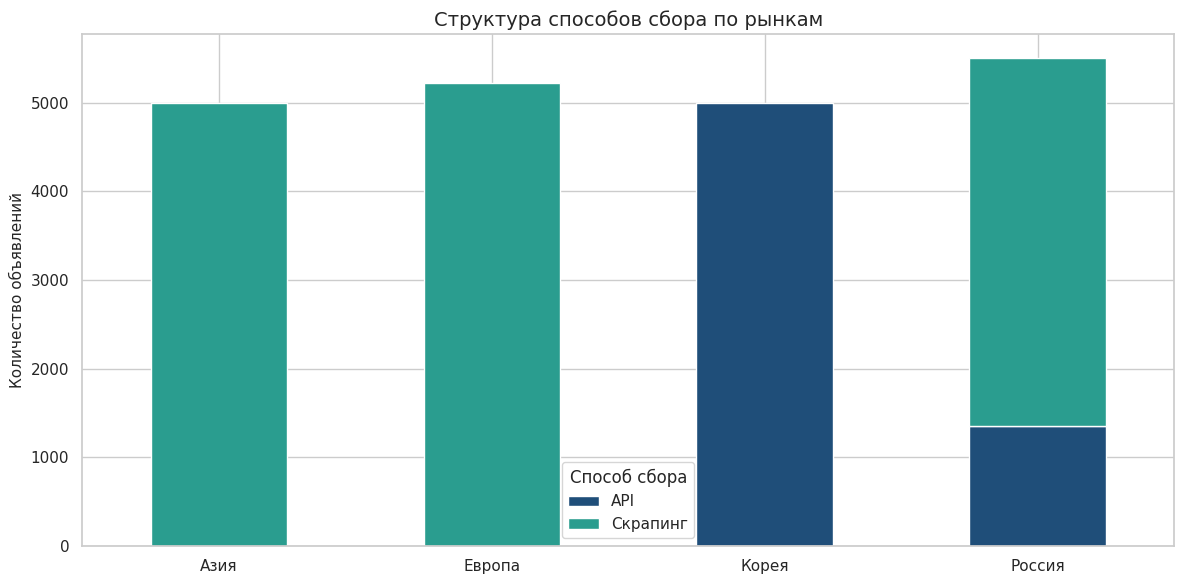

In [17]:
source_mix = (
    all_cars.groupby(["market_name", "collection_method"])
    .size()
    .reset_index(name="rows")
)
source_mix = rename_columns(
    source_mix,
    {
        "market_name": "Рынок",
        "collection_method": "Способ сбора",
        "rows": "Количество объявлений",
    },
)
display(source_mix)

pivot_source = source_mix.pivot(index="Рынок", columns="Способ сбора", values="Количество объявлений").fillna(0)
pivot_source.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Структура способов сбора по рынкам")
plt.xlabel("")
plt.ylabel("Количество объявлений")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Этот блок нужен для того, чтобы показать структуру сбора данных. Здесь видно, какие рынки больше опираются на API, какие на scraping, и как в целом устроен наш датасет по методам получения данных.

In [18]:
top_brands = (
    all_cars.groupby("brand", dropna=False)
    .agg(
        rows=("link", "count"),
        median_total_rub=("estimated_total_rub", "median"),
        median_year=("year", "median"),
    )
    .reset_index()
    .sort_values("rows", ascending=False)
    .head(15)
    .rename(
        columns={
            "brand": "Марка",
            "rows": "Количество объявлений",
            "median_total_rub": "Медианная итоговая цена, руб.",
            "median_year": "Медианный год",
        }
    )
)
display(top_brands)


,Марка,Количество объявлений,"Медианная итоговая цена, руб.",Медианный год
67,Kia,3651,2 355 007,2 021
121,Toyota,2297,1 897 986,2 015
52,Hyundai,2260,2 176 803,2 021
11,BMW,1467,10 204 854,2 022
91,Nissan,1328,1 704 107,2 017
8,Audi,1137,6 702 078,2 022
98,Porsche,1089,11 987 444,2 019
123,Volkswagen,973,2 158 888,2 022
84,Mazda,705,1 699 000,2 017
45,Genesis,610,3 666 422,2 022


Дальше мы перешли к маркам. Такой срез помогает понять, какие бренды сильнее всего представлены в данных и по каким маркам можно делать более уверенные выводы.

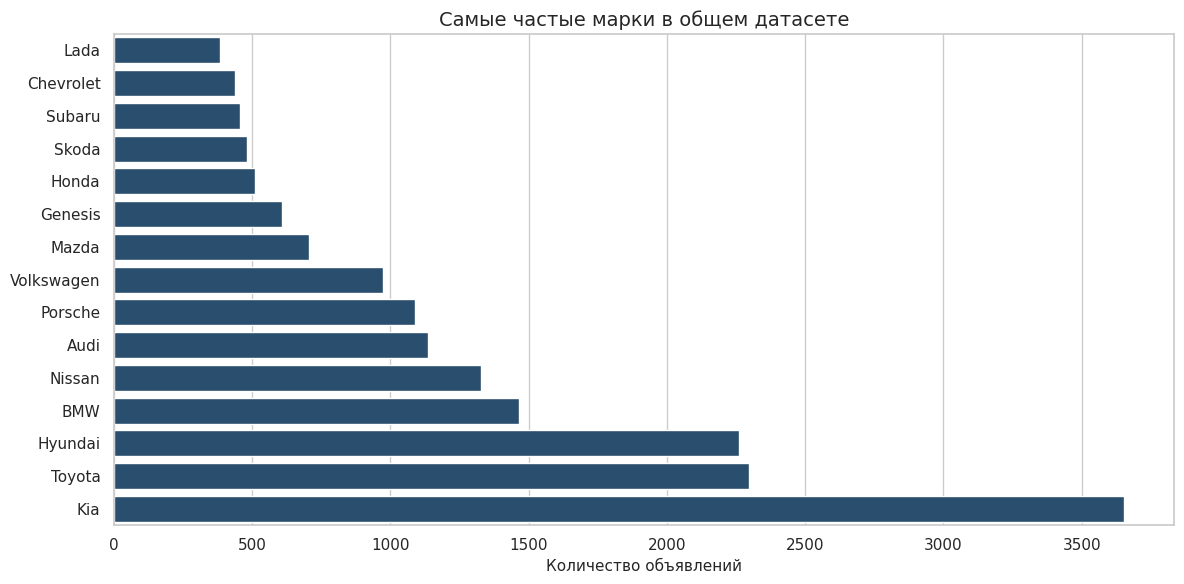

In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_brands.sort_values("Количество объявлений", ascending=True), x="Количество объявлений", y="Марка")
plt.title("Самые частые марки в общем датасете")
plt.xlabel("Количество объявлений")
plt.ylabel("")
plt.tight_layout()
plt.show()


На этом графике видно, какие марки формируют основной объем выборки. Это полезно и для анализа структуры рынка, и для оценки того, по каким брендам у нас достаточно наблюдений для сравнений.

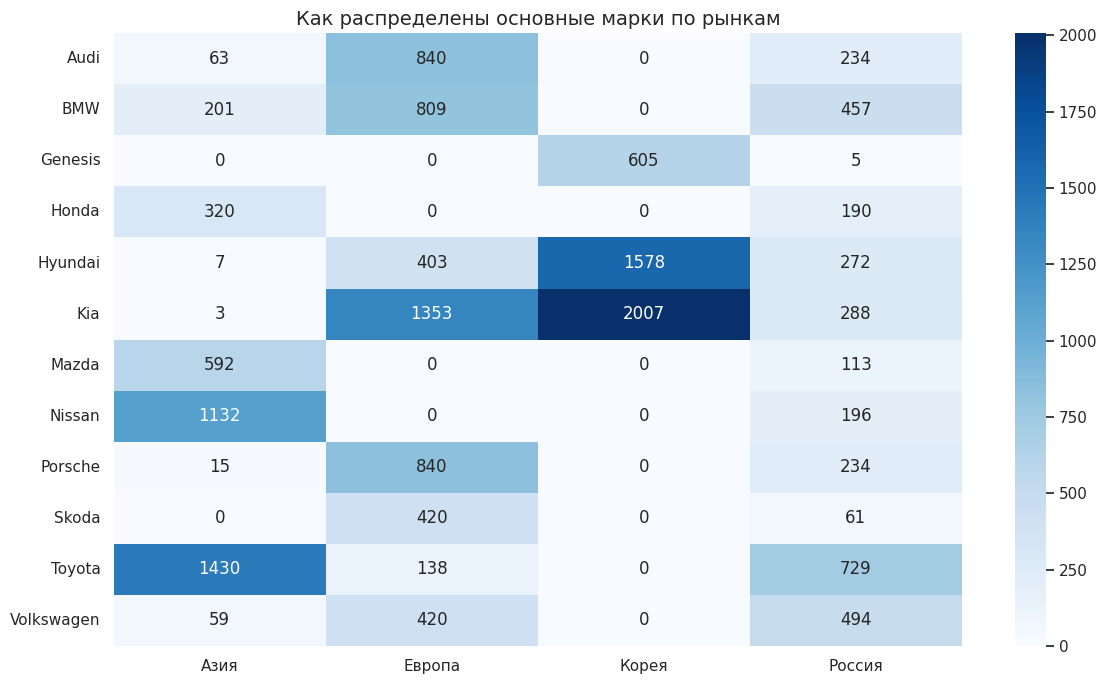

In [20]:
brand_market_pivot = (
    all_cars.groupby(["market_name", "brand"])
    .size()
    .reset_index(name="rows")
)
top_brand_list = all_cars["brand"].value_counts().head(12).index.tolist()
brand_market_pivot = brand_market_pivot[brand_market_pivot["brand"].isin(top_brand_list)]
brand_market_pivot = replace_values(brand_market_pivot)
heatmap_table = brand_market_pivot.pivot(index="brand", columns="market_name", values="rows").fillna(0)

plt.figure(figsize=(12, 7))
sns.heatmap(heatmap_table, annot=True, fmt=".0f", cmap="Blues")
plt.title("Как распределены основные марки по рынкам")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()


Тепловая карта показывает, какие марки сильнее представлены в разных частях выборки. Так проще заметить, где рынок более немецкий, где больше корейских машин, а где заметнее японское направление.

In [21]:
model_table = (
    all_cars.groupby("model_key", dropna=False)
    .agg(
        rows=("link", "count"),
        median_total_rub=("estimated_total_rub", "median"),
        median_year=("year", "median"),
    )
    .reset_index()
    .sort_values("rows", ascending=False)
    .head(20)
    .rename(
        columns={
            "model_key": "Модель",
            "rows": "Количество объявлений",
            "median_total_rub": "Медианная итоговая цена, руб.",
            "median_year": "Медианный год",
        }
    )
)
display(model_table)


,Модель,Количество объявлений,"Медианная итоговая цена, руб.",Медианный год
1354,Kia Sorento,736,6 238 128,2 022
1646,Nissan X-Trail,639,1 789 547,2 017
1058,Kia Carnival,629,5 847 394,2 021
1685,Porsche Panamera,623,12 600 469,2 019
71,BMW X5,615,9 971 183,2 022
1280,Kia Picanto,539,1 320 000,2 020
1862,Toyota Alphard,534,4 525 000,2 013
922,Hyundai Tucson,518,3 790 974,2 022
74,BMW X7,501,14 721 494,2 024
2021,Volkswagen Tiguan,475,3 303 672,2 022


После марок мы посмотрели на модели. Этот срез особенно важен для проекта, потому что именно на уровне моделей потом строится сравнение между Россией и зарубежными рынками.

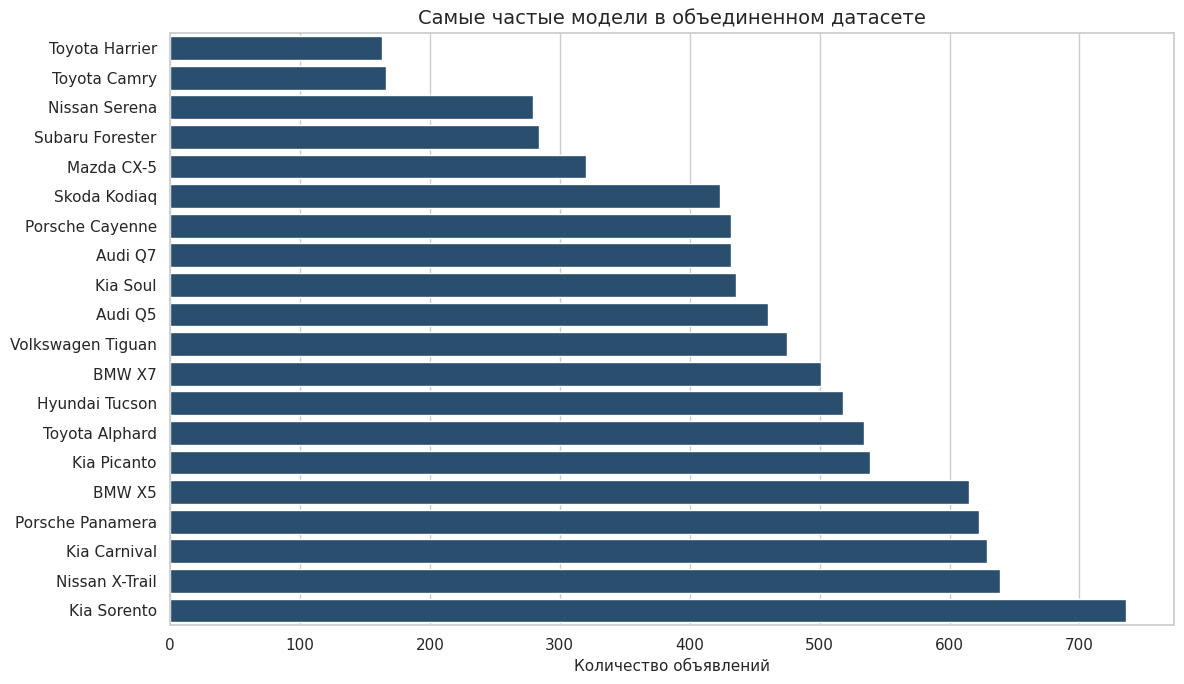

In [22]:
plt.figure(figsize=(12, 7))
sns.barplot(data=model_table.sort_values("Количество объявлений", ascending=True), x="Количество объявлений", y="Модель")
plt.title("Самые частые модели в объединенном датасете")
plt.xlabel("Количество объявлений")
plt.ylabel("")
plt.tight_layout()
plt.show()


Здесь видно, какие модели встречаются чаще всего. Это помогает понять, по каким машинам у нас самая плотная выборка и где можно делать более уверенные сравнительные выводы.

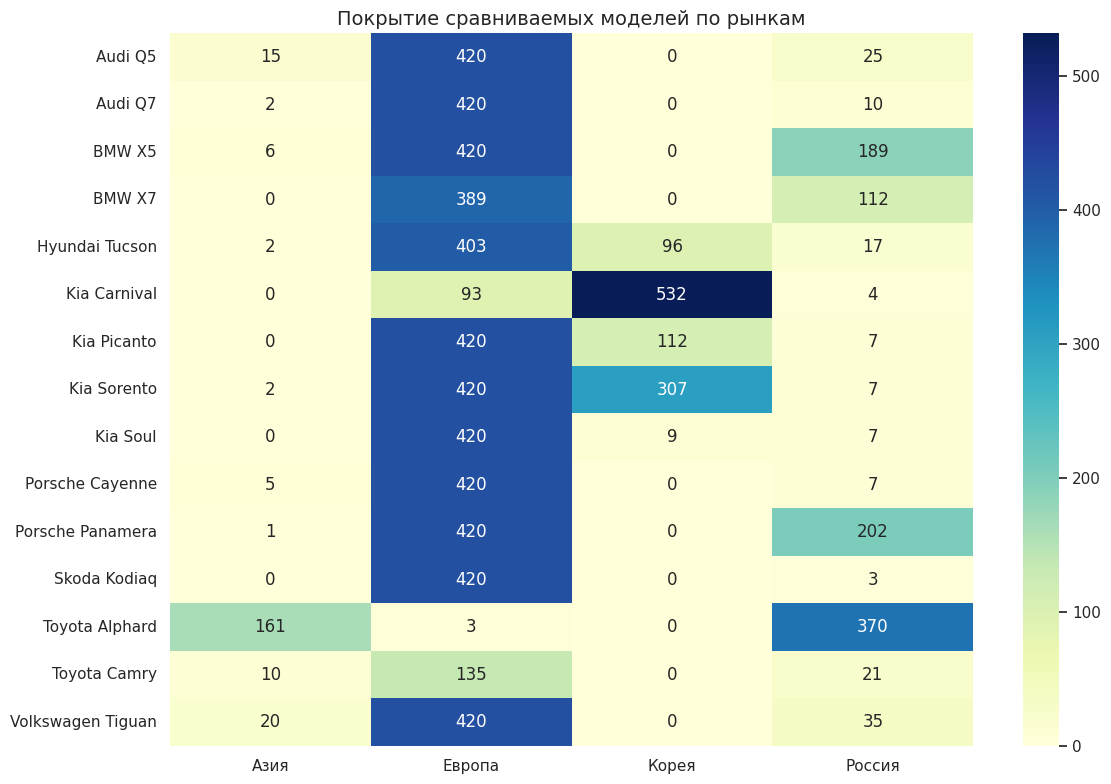

In [23]:
target_cover = (
    all_cars.groupby(["market_name", "model_key"])
    .size()
    .reset_index(name="rows")
)
target_cover = target_cover[target_cover["model_key"].isin(comparison_df["model_key"].dropna().unique())]
target_cover = replace_values(target_cover)
target_pivot = target_cover.pivot(index="model_key", columns="market_name", values="rows").fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(target_pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Покрытие сравниваемых моделей по рынкам")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()


Эта тепловая карта нужна именно для сравнительной части. Она показывает, по каким моделям у нас реально есть достаточное покрытие сразу в нескольких рынках, а по каким выборка уже заметно уже.

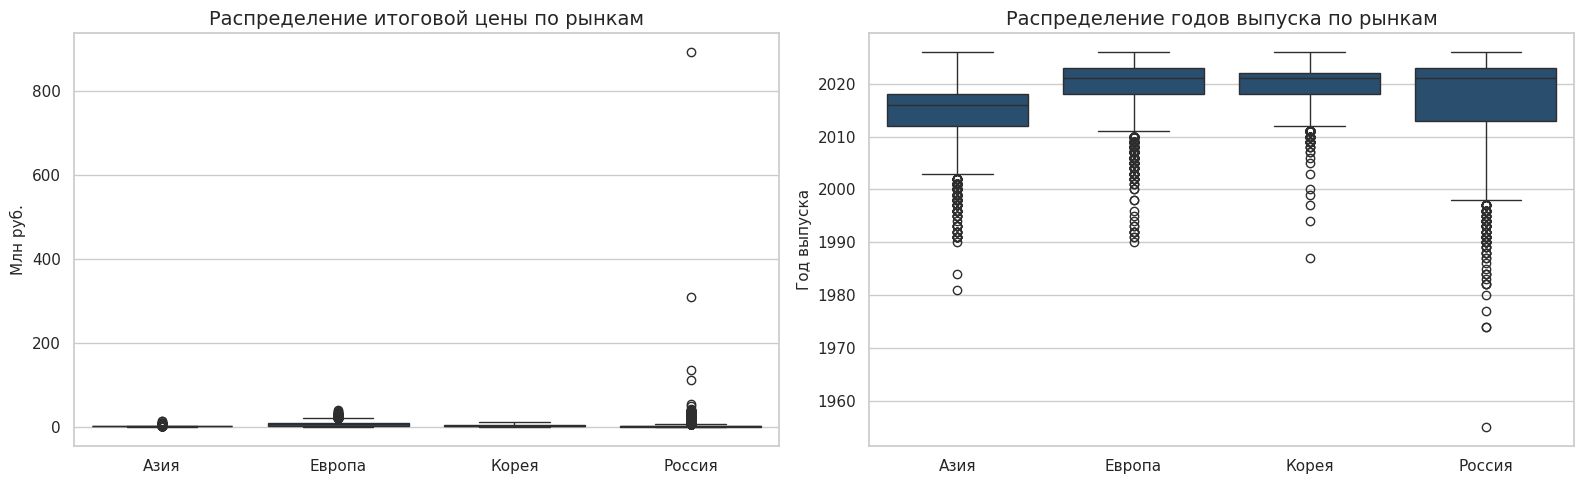

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

price_box = replace_values(all_cars[["market_name", "estimated_total_rub"]].dropna())
price_box["Итоговая цена, млн руб."] = price_box["estimated_total_rub"] / 1_000_000
sns.boxplot(data=price_box, x="market_name", y="Итоговая цена, млн руб.", ax=axes[0])
axes[0].set_title("Распределение итоговой цены по рынкам")
axes[0].set_xlabel("")
axes[0].set_ylabel("Млн руб.")

year_box = replace_values(all_cars[["market_name", "year"]].dropna())
sns.boxplot(data=year_box, x="market_name", y="year", ax=axes[1])
axes[1].set_title("Распределение годов выпуска по рынкам")
axes[1].set_xlabel("")
axes[1].set_ylabel("Год выпуска")

plt.tight_layout()
plt.show()


Эти графики помогают увидеть не только медианы, но и разброс данных. По ним хорошо видно, где рынок более дорогой, где больше свежих автомобилей и где внутри выборки сильнее размах значений.

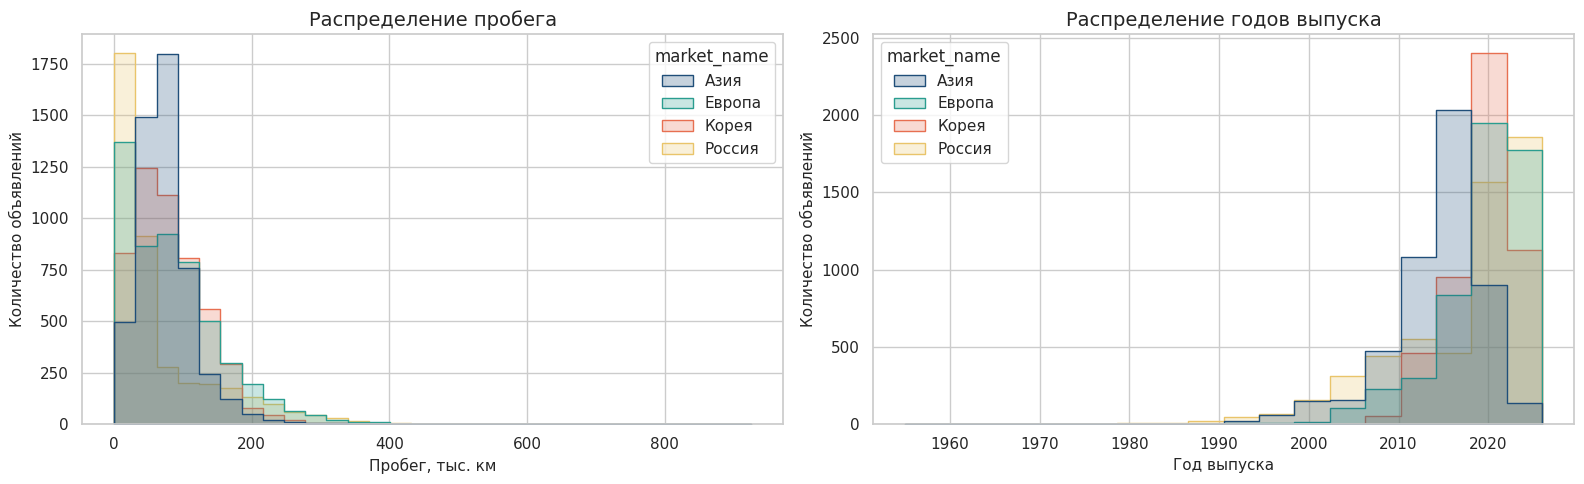

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

mileage_data = replace_values(all_cars[["market_name", "mileage_km"]].dropna())
mileage_data["Пробег, тыс. км"] = mileage_data["mileage_km"] / 1_000
sns.histplot(data=mileage_data, x="Пробег, тыс. км", hue="market_name", element="step", bins=30, ax=axes[0], common_norm=False)
axes[0].set_title("Распределение пробега")
axes[0].set_xlabel("Пробег, тыс. км")
axes[0].set_ylabel("Количество объявлений")

year_data = replace_values(all_cars[["market_name", "year"]].dropna())
sns.histplot(data=year_data, x="year", hue="market_name", element="step", bins=18, ax=axes[1], common_norm=False)
axes[1].set_title("Распределение годов выпуска")
axes[1].set_xlabel("Год выпуска")
axes[1].set_ylabel("Количество объявлений")

plt.tight_layout()
plt.show()


Если прошлые графики показывали разброс, то эти помогают увидеть форму распределения. Так проще заметить, где рынок смещен к свежим машинам, а где больше автомобилей с крупным пробегом.

In [26]:
cost_table = (
    all_cars.groupby("market_name", dropna=False)
    .agg(
        median_price_rub=("price_rub", "median"),
        median_duty=("customs_duty_rub", "median"),
        median_clearance=("customs_clearance_rub", "median"),
        median_delivery=("delivery_rub", "median"),
        median_docs=("certification_rub", "median"),
        median_service=("broker_service_rub", "median"),
        median_util=("util_fee_rub", "median"),
        median_total=("estimated_total_rub", "median"),
    )
    .reset_index()
)
cost_table = rename_columns(
    cost_table,
    {
        "market_name": "Рынок",
        "median_price_rub": "Медианная цена, руб.",
        "median_duty": "Медианная пошлина, руб.",
        "median_clearance": "Медианное оформление, руб.",
        "median_delivery": "Медианная доставка, руб.",
        "median_docs": "Медианные документы, руб.",
        "median_service": "Медианный сервисный сбор, руб.",
        "median_util": "Медианный утильсбор, руб.",
        "median_total": "Медианная итоговая цена, руб.",
    },
)
display(cost_table)


,Рынок,"Медианная цена, руб.","Медианная пошлина, руб.","Медианное оформление, руб.","Медианная доставка, руб.","Медианные документы, руб.","Медианный сервисный сбор, руб.","Медианный утильсбор, руб.","Медианная итоговая цена, руб."
0,Азия,542 502,862 819,4 924,250 000,35 000,30 000,5 200,1 689 560
1,Европа,3 006 401,864 115,18 465,180 000,35 000,20 000,2 011 200,6 369 490
2,Корея,1 179 714,534 428,4 924,250 000,35 000,30 000,5 200,2 258 814
3,Россия,1 699 000,0,0,0,0,0,0,1 699 000


Здесь мы уже перешли к структуре итоговой цены. Теперь таблица показывает не общие слова вроде логистики и брокера, а конкретные части расчета: пошлину, оформление, доставку, документы, сервисный сбор и утильсбор.

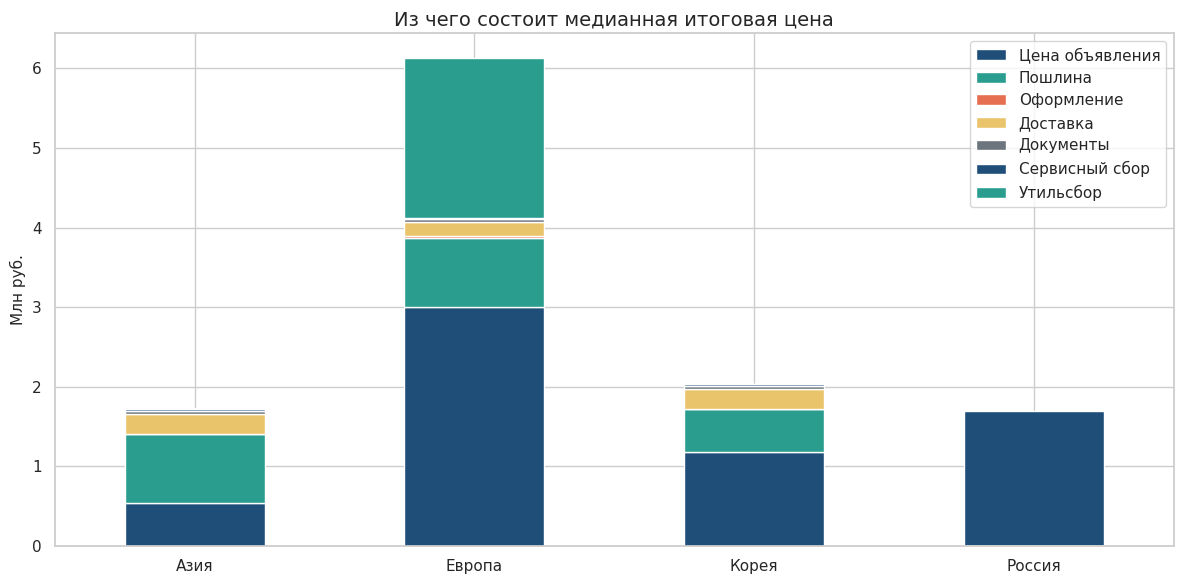

In [27]:
stacked = all_cars.groupby("market_name", dropna=False)[
    [
        "price_rub",
        "customs_duty_rub",
        "customs_clearance_rub",
        "delivery_rub",
        "certification_rub",
        "broker_service_rub",
        "util_fee_rub",
    ]
].median().reset_index()
stacked = replace_values(stacked).rename(columns={"market_name": "Рынок"})
stacked = stacked.rename(
    columns={
        "price_rub": "Цена объявления",
        "customs_duty_rub": "Пошлина",
        "customs_clearance_rub": "Оформление",
        "delivery_rub": "Доставка",
        "certification_rub": "Документы",
        "broker_service_rub": "Сервисный сбор",
        "util_fee_rub": "Утильсбор",
    }
)
stacked = stacked.set_index("Рынок") / 1_000_000
stacked.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Из чего состоит медианная итоговая цена")
plt.xlabel("")
plt.ylabel("Млн руб.")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Столбчатая диаграмма помогает визуально увидеть структуру цены. На ней сразу заметно, какую долю дают сама цена объявления, пошлина, оформление, доставка, документы и утильсбор.

In [28]:
share_table = all_cars.groupby("market_name", dropna=False)[
    [
        "price_rub",
        "customs_duty_rub",
        "customs_clearance_rub",
        "delivery_rub",
        "certification_rub",
        "broker_service_rub",
        "util_fee_rub",
    ]
].median().reset_index()
share_table["total_rub"] = share_table[
    [
        "price_rub",
        "customs_duty_rub",
        "customs_clearance_rub",
        "delivery_rub",
        "certification_rub",
        "broker_service_rub",
        "util_fee_rub",
    ]
].sum(axis=1)
for column in [
    "price_rub",
    "customs_duty_rub",
    "customs_clearance_rub",
    "delivery_rub",
    "certification_rub",
    "broker_service_rub",
    "util_fee_rub",
]:
    share_table[column] = (share_table[column] / share_table["total_rub"] * 100).round(1)
share_table = rename_columns(
    share_table,
    {
        "market_name": "Рынок",
        "price_rub": "Доля цены объявления, %",
        "customs_duty_rub": "Доля пошлины, %",
        "customs_clearance_rub": "Доля оформления, %",
        "delivery_rub": "Доля доставки, %",
        "certification_rub": "Доля документов, %",
        "broker_service_rub": "Доля сервисного сбора, %",
        "util_fee_rub": "Доля утильсбора, %",
    },
)
display(
    share_table[
        [
            "Рынок",
            "Доля цены объявления, %",
            "Доля пошлины, %",
            "Доля оформления, %",
            "Доля доставки, %",
            "Доля документов, %",
            "Доля сервисного сбора, %",
            "Доля утильсбора, %",
        ]
    ]
)


,Рынок,"Доля цены объявления, %","Доля пошлины, %","Доля оформления, %","Доля доставки, %","Доля документов, %","Доля сервисного сбора, %","Доля утильсбора, %"
0,Азия,31,50,0,14,2,2,0
1,Европа,49,14,0,3,1,0,33
2,Корея,58,26,0,12,2,2,0
3,Россия,100,0,0,0,0,0,0


Эта таблица показывает структуру цены уже в процентах. По ней проще объяснить, почему один рынок выглядит выгоднее, а другой становится дороже после ввоза.

In [29]:
util_profile = (
    all_cars[all_cars["market"] != "RU"]
    .assign(
        age_group=lambda df: pd.cut(
            2026 - df["year"],
            bins=[-1, 2, 5, 100],
            labels=["до 3 лет", "3-5 лет", "старше 5 лет"],
        )
    )
    .groupby(["market_name", "age_group"], dropna=False)
    .agg(
        rows=("link", "count"),
        median_power_hp=("power_hp", "median"),
        median_util_fee_rub=("util_fee_rub", "median"),
    )
    .reset_index()
)
util_profile = rename_columns(
    util_profile,
    {
        "market_name": "Рынок",
        "age_group": "Возрастная группа",
        "rows": "Количество строк",
        "median_power_hp": "Медианная мощность, л.с.",
        "median_util_fee_rub": "Медианный утильсбор, руб.",
    },
)
display(util_profile)


,Рынок,Возрастная группа,Количество строк,"Медианная мощность, л.с.","Медианный утильсбор, руб."
0,Азия,до 3 лет,71,NaN,3 400
1,Азия,3-5 лет,260,250,5 200
2,Азия,старше 5 лет,4669,250,5 200
3,Европа,до 3 лет,1269,215,1 142 400
4,Европа,3-5 лет,1718,231,1 838 400
5,Европа,старше 5 лет,2236,204,3 501 600
6,Корея,до 3 лет,501,200,3 400
7,Корея,3-5 лет,2308,200,5 200
8,Корея,старше 5 лет,2191,200,5 200


Этим блоком мы объясняем, почему в Европе итоговая цена часто выше. Там больше свежих и мощных машин, поэтому утильсбор и часть сопутствующих расходов заметнее, чем в Корее и в остальной Азии.

In [30]:
missing_table = pd.DataFrame(
    {
        "Колонка": all_cars.columns,
        "Пропусков": all_cars.isna().sum().values,
        "Доля пропусков, %": (all_cars.isna().mean().values * 100).round(2),
    }
).sort_values(["Пропусков", "Колонка"], ascending=[False, True])
display(missing_table.head(15))


,Колонка,Пропусков,"Доля пропусков, %"
22,api_class,15329,74
19,api_cylinders,15329,74
20,api_drive,15329,74
18,api_engine_cc,15329,74
21,api_fuel_type,15329,74
24,api_source,15329,74
23,api_transmission,15329,74
14,power_hp,13204,64
9,mileage_km,1533,7
13,engine_cc,1,0


Этим блоком мы посмотрели на пропуски. Он нужен для того, чтобы честно показать качество данных и сразу понять, какие характеристики в источниках заполняются лучше, а какие хуже.

In [31]:
outlier_rows = []
for column in ["price_rub", "estimated_total_rub", "mileage_km", "year"]:
    series = pd.to_numeric(all_cars[column], errors="coerce").dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = int(((series < lower) | (series > upper)).sum())
    outlier_rows.append(
        {
            "Колонка": column,
            "Q1": round(float(q1), 2),
            "Q3": round(float(q3), 2),
            "IQR": round(float(iqr), 2),
            "Нижняя граница": round(float(lower), 2),
            "Верхняя граница": round(float(upper), 2),
            "Число выбросов": outliers,
            "Доля выбросов, %": round(float(outliers / len(series) * 100), 2),
        }
    )
outlier_table = pd.DataFrame(outlier_rows)
display(outlier_table)


,Колонка,Q1,Q3,IQR,Нижняя граница,Верхняя граница,Число выбросов,"Доля выбросов, %"
0,price_rub,605 234,2 498 576,1 893 342,-2 234 780,5 338 590,2074,10
1,estimated_total_rub,1 450 000,5 706 172,4 256 172,-4 934 258,12 090 430,1255,6
2,mileage_km,33 000,105 598,72 598,-75 898,214 496,676,4
3,year,2 015,2 022,7,2 004,2 032,794,4


Отдельно мы проверили выбросы. Это полезно, потому что на автомобильном рынке часто встречаются очень дорогие машины, почти новые автомобили или, наоборот, сильно уставшие варианты, которые могут искажать общую картину.

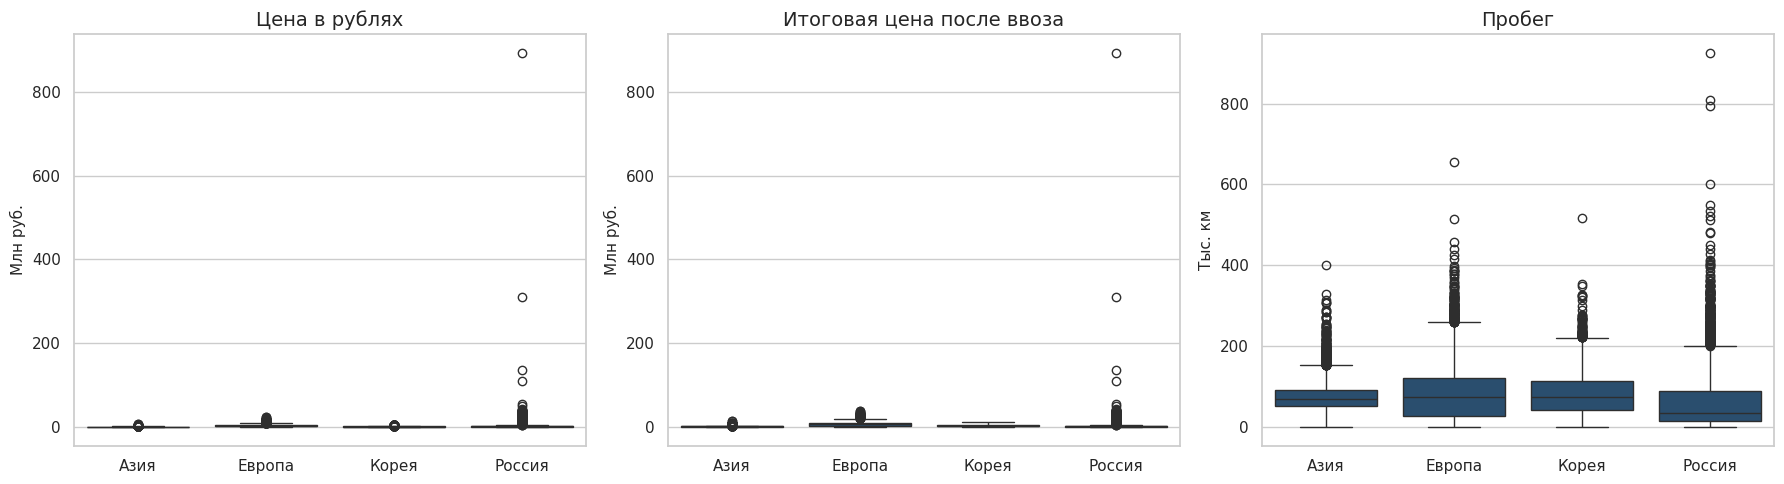

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

outlier_price = replace_values(all_cars[["market_name", "price_rub"]].dropna())
outlier_price["Цена, млн руб."] = outlier_price["price_rub"] / 1_000_000
sns.boxplot(data=outlier_price, x="market_name", y="Цена, млн руб.", ax=axes[0])
axes[0].set_title("Цена в рублях")
axes[0].set_xlabel("")
axes[0].set_ylabel("Млн руб.")

outlier_total = replace_values(all_cars[["market_name", "estimated_total_rub"]].dropna())
outlier_total["Итоговая цена, млн руб."] = outlier_total["estimated_total_rub"] / 1_000_000
sns.boxplot(data=outlier_total, x="market_name", y="Итоговая цена, млн руб.", ax=axes[1])
axes[1].set_title("Итоговая цена после ввоза")
axes[1].set_xlabel("")
axes[1].set_ylabel("Млн руб.")

outlier_mileage = replace_values(all_cars[["market_name", "mileage_km"]].dropna())
outlier_mileage["Пробег, тыс. км"] = outlier_mileage["mileage_km"] / 1_000
sns.boxplot(data=outlier_mileage, x="market_name", y="Пробег, тыс. км", ax=axes[2])
axes[2].set_title("Пробег")
axes[2].set_xlabel("")
axes[2].set_ylabel("Тыс. км")

plt.tight_layout()
plt.show()


Эти графики дополняют таблицу по выбросам. Они помогают глазами увидеть, насколько сильно рынки отличаются по разбросу цен и пробегов и где внутри рынка встречаются особенно крайние наблюдения.

In [33]:
comparison_view = rename_columns(
    comparison_df,
    {
        "model_key": "Модель",
        "foreign_market": "Зарубежный рынок",
        "foreign_median_year": "Медианный год за рубежом",
        "foreign_rows": "Строк за рубежом",
        "russia_rows_matched": "Сопоставлено строк из России",
        "foreign_median_price_rub": "Медианная цена за рубежом, руб.",
        "imported_median_price_rub": "Медианная цена после ввоза, руб.",
        "russia_median_price_rub": "Медианная цена в России, руб.",
        "price_gap_rub": "Разница с Россией, руб.",
        "decision": "Вывод",
    },
)
display(comparison_view)


,Модель,Зарубежный рынок,Медианный год за рубежом,Строк за рубежом,Сопоставлено строк из России,"Медианная цена за рубежом, руб.","Медианная цена после ввоза, руб.","Медианная цена в России, руб.","Разница с Россией, руб.",Вывод
0,Audi Q7,Азия,2016,2,10,862091,5322981,9355010,-4032029,Ввоз дешевле
1,Audi Q5,Азия,2016,15,10,763258,5047778,7799500,-2751722,Ввоз дешевле
2,Audi Q5,Европа,2022,420,10,3321443,5976022,8349500,-2373478,Ввоз дешевле
3,BMW X7,Европа,2024,389,10,7714028,14731460,15222500,-491040,Ввоз дешевле
4,Kia Picanto,Корея,2016,112,7,314158,898780,1229900,-331120,Ввоз дешевле
5,Volkswagen Tiguan,Азия,2016,20,10,438743,1174554,1448000,-273446,Ввоз дешевле
6,Audi Q7,Европа,2020,420,10,4203020,9438402,9355010,83392,Покупка в России дешевле
7,Kia Soul,Корея,2011,9,7,270243,1094137,960000,134137,Покупка в России дешевле
8,Kia Picanto,Европа,2021,420,7,977980,1415816,1229900,185916,Покупка в России дешевле
9,Hyundai Tucson,Корея,2021,96,10,1194786,3352036,2765000,587036,Покупка в России дешевле


Здесь мы собрали главную сравнительную таблицу проекта. Именно она показывает, какие модели после ввоза выглядят выгоднее, а где российский рынок пока выигрывает.

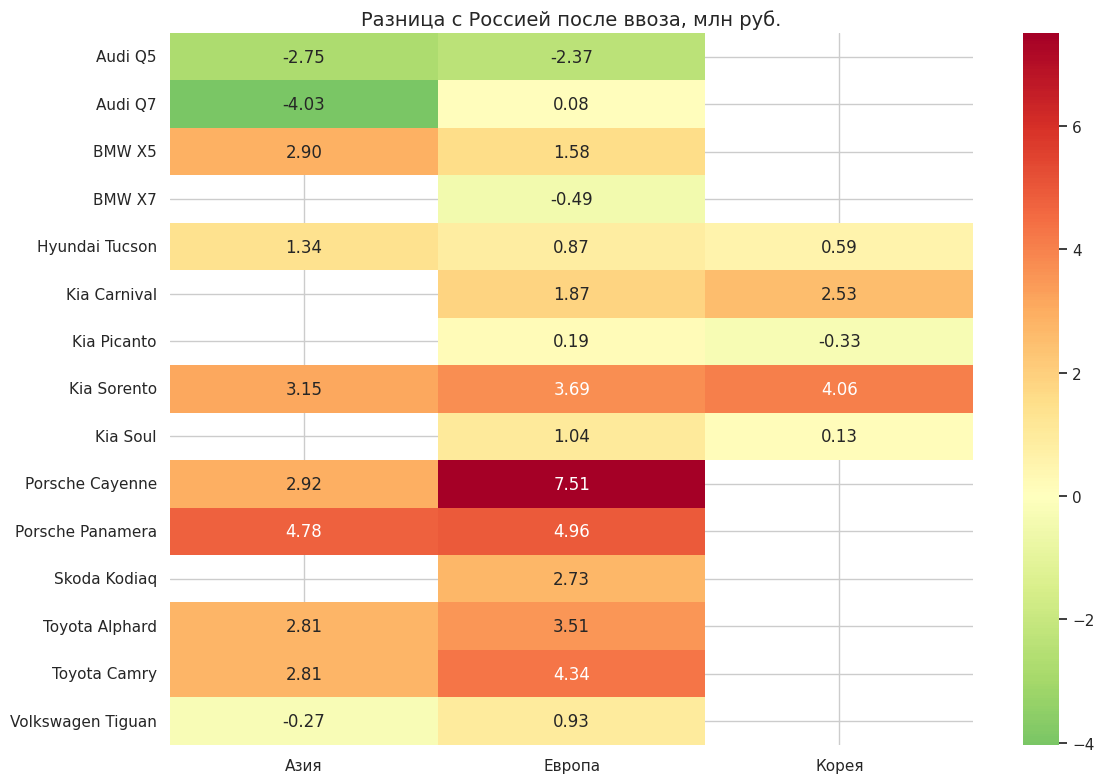

In [34]:
if not comparison_df.empty:
    comparison_heatmap = comparison_df.pivot_table(
        index="model_key",
        columns="foreign_market",
        values="price_gap_rub",
        aggfunc="median",
    ) / 1_000_000
    comparison_heatmap = comparison_heatmap.rename(
        columns={"Europe": "Европа", "Korea": "Корея", "Asia": "Азия"}
    )
    plt.figure(figsize=(12, 8))
    sns.heatmap(comparison_heatmap, annot=True, fmt=".2f", cmap="RdYlGn_r", center=0)
    plt.title("Разница с Россией после ввоза, млн руб.")
    plt.xlabel("")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


Тепловая карта делает сравнительную часть гораздо нагляднее. Отрицательные значения означают, что ввоз оказывается дешевле, а положительные — что покупка в России сейчас выгоднее.

In [35]:
best_cases = rename_columns(
    comparison_df.nsmallest(5, "price_gap_rub"),
    {
        "model_key": "Модель",
        "foreign_market": "Зарубежный рынок",
        "imported_median_price_rub": "Цена после ввоза, руб.",
        "russia_median_price_rub": "Цена в России, руб.",
        "price_gap_rub": "Разница, руб.",
        "decision": "Вывод",
    },
)[
    ["Модель", "Зарубежный рынок", "Цена после ввоза, руб.", "Цена в России, руб.", "Разница, руб.", "Вывод"]
]

worst_cases = rename_columns(
    comparison_df.nlargest(5, "price_gap_rub"),
    {
        "model_key": "Модель",
        "foreign_market": "Зарубежный рынок",
        "imported_median_price_rub": "Цена после ввоза, руб.",
        "russia_median_price_rub": "Цена в России, руб.",
        "price_gap_rub": "Разница, руб.",
        "decision": "Вывод",
    },
)[
    ["Модель", "Зарубежный рынок", "Цена после ввоза, руб.", "Цена в России, руб.", "Разница, руб.", "Вывод"]
]

display(best_cases)
display(worst_cases)


,Модель,Зарубежный рынок,"Цена после ввоза, руб.","Цена в России, руб.","Разница, руб.",Вывод
0,Audi Q7,Азия,5322981,9355010,-4032029,Ввоз дешевле
1,Audi Q5,Азия,5047778,7799500,-2751722,Ввоз дешевле
2,Audi Q5,Европа,5976022,8349500,-2373478,Ввоз дешевле
3,BMW X7,Европа,14731460,15222500,-491040,Ввоз дешевле
4,Kia Picanto,Корея,898780,1229900,-331120,Ввоз дешевле


,Модель,Зарубежный рынок,"Цена после ввоза, руб.","Цена в России, руб.","Разница, руб.",Вывод
29,Porsche Cayenne,Европа,11659214,4150000,7509214,Покупка в России дешевле
28,Porsche Panamera,Европа,12400565,7444500,4956065,Покупка в России дешевле
27,Porsche Panamera,Азия,8031093,3250000,4781093,Покупка в России дешевле
26,Toyota Camry,Европа,7113080,2775000,4338080,Покупка в России дешевле
25,Kia Sorento,Корея,6331475,2269000,4062475,Покупка в России дешевле


Эти две таблицы выделяют крайние случаи. В первой мы видим самые интересные варианты для ввоза, а во второй — те модели, где российский рынок сейчас выглядит заметно сильнее.

In [36]:
summary_lines = [translate_text(x) for x in summarize_comparison(comparison_df).split("\n")]
summary_df = pd.DataFrame({"Короткий итог по сравнению": summary_lines})
display(summary_df)


,Короткий итог по сравнению
0,Самый выгодный импортный сценарий сейчас у мод...
1,Самый слабый вариант импорта у модели Porsche ...


В конце аналитического раздела мы сделали короткий текстовый итог. Он помогает быстро собрать главную мысль после всех таблиц и графиков.

## 5. Бизнес-вывод для заказчика

In [37]:
business_lines = [translate_text(x) for x in business_summary(all_cars, comparison_df)]

if not comparison_df.empty:
    best_import = comparison_df.nsmallest(3, "price_gap_rub")[["model_key", "foreign_market", "price_gap_rub"]].copy()
    best_import = replace_values(best_import)
    best_import["price_gap_rub"] = best_import["price_gap_rub"].round(0)
else:
    best_import = pd.DataFrame(columns=["model_key", "foreign_market", "price_gap_rub"])

business_table = pd.DataFrame({"Вывод": business_lines})
display(business_table)
display(best_import.rename(columns={"model_key": "Модель", "foreign_market": "Рынок", "price_gap_rub": "Разница с Россией, руб."}))


,Вывод
0,Самый большой пласт данных пришёл из рынка Евр...
1,Самая низкая медианная итоговая цена сейчас у ...
2,Самая заметная марка в объединённой выборке — ...
3,По сравнительной части самый сильный кейс — Au...


,Модель,Рынок,"Разница с Россией, руб."
0,Audi Q7,Азия,-4032029
1,Audi Q5,Азия,-2751722
2,Audi Q5,Европа,-2373478


В финале мы свели результат к бизнес-языку. Здесь уже не просто числа, а короткие выводы о том, какие рынки выглядят интереснее, где сейчас есть потенциал для более выгодной закупки и на какие модели стоит смотреть в первую очередь.